In [1]:
import os

train_dir = './coco/images/train/'
train_annotation = './coco/annotations/instances_attributes_train2020.json'
seg_train = './coco/segmentations/seg_train/'
val_dir = './coco/images/val/'
val_annotation = './coco/annotations/instances_attributes_val2020.json'
seg_val = './coco/segmentations/seg_val/'

TARGETH = 1024
TARGETW = 683


print('Train contains:', len(os.listdir(train_dir)), 'images')
print('Seg_train contains:',len(os.listdir(seg_train)), 'images')
print('Validation contains:',len(os.listdir(val_dir)), 'images')
print('Seg_val contains:',len(os.listdir(seg_val)), 'images')
#print('Test contains:',len(os.listdir('./coco//content/test/')), 'images')

Train contains: 45623 images
Seg_train contains: 45623 images
Validation contains: 3200 images
Seg_val contains: 1158 images


In [2]:
#enèssim intent, istg que em matarà aquesta pràctica

In [3]:
import matplotlib.pyplot as plt
import cv2
import os
import torch
from PIL import Image
import numpy as np
from torch.utils.data import Dataset
from torch.utils.data import random_split
from pycocotools.coco import COCO
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

if torch.cuda.is_available():
    device=torch.device("cuda")
else:
    device=torch.device("cpu")

device=torch.device("cpu")
print(device)
"""
Output must be--> device(type='cuda')
"""

cpu


"\nOutput must be--> device(type='cuda')\n"

In [4]:


# Custom PyTorch Dataset to load COCO-format annotations and images
class FashionDatasetMaskRCNN(Dataset):
    # Init function: loads annotation file and prepares list of image id's
    def __init__(self, root_dir, annotation_file, transforms=None):
        """
        root_dir: path to the folder containing images (e.g. car_parts_dataset/train/)
        annotation_file: path to the COCO annotations (e.g. car_parts_dataset/train/_annotations.coco.json)
        """
        self.root_dir = root_dir  # Directory where images are stored
        self.coco = COCO(annotation_file)  # Load COCO annotations
        self.image_ids = list(self.coco.imgs.keys())  # Extract all image IDs
        self.transforms = transforms  # Optional image transformations
     
    # Returns total number of images
    def __len__(self):
        return len(self.image_ids)  # Total number of images
 
    # Fetches a single image and its annotations
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]  # Get image ID from list
        image_info = self.coco.loadImgs(image_id)[0]  # Load image info (e.g. filename)
        image_path = os.path.join(self.root_dir, image_info["file_name"])  # Construct full path
        image = Image.open(image_path).convert("RGB")  # Load and convert image to RGB
         
        # Load all annotations for this image
        annotation_ids = self.coco.getAnnIds(imgIds=image_id)  # Get annotation IDs for image
        annotations = self.coco.loadAnns(annotation_ids)  # Load annotation details
         
        # Extract segmentation masks, bounding boxes and labels from annotations
        boxes = []  # List to store bounding boxes
        labels = []  # List to store category labels
        masks = []  # List to store segmentation masks
         
        for ann in annotations:
            if ann["category_id"]>27:continue
            xmin, ymin, w, h = ann['bbox']  # Get bounding box in COCO format (x, y, width, height)
            xmax = xmin + w  # Calculate bottom-right x
            ymax = ymin + h  # Calculate bottom-right y
            boxes.append([xmin, ymin, xmax, ymax])  # Append box in (xmin, ymin, xmax, ymax) format
            labels.append(ann['category_id'])  # Append category ID
            mask = self.coco.annToMask(ann)  # Convert segmentation to binary mask
            masks.append(mask)  # Append mask
         
        # Convert annotations to PyTorch tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)  # Bounding boxes as float tensors
        labels = torch.as_tensor(labels, dtype=torch.int64)  # Labels as int64 tensors
        masks = torch.as_tensor(masks, dtype=torch.uint8)  # Masks as uint8 tensors
        area = torch.as_tensor([ann['area'] for ann in annotations], dtype=torch.float32)  # Area of each object
        iscrowd = torch.as_tensor([ann.get('iscrowd', 0) for ann in annotations], dtype=torch.int64)  # Crowd annotations
         
        # store everything in a dictionary
        target = {
            "boxes": boxes,  # Bounding boxes
            "labels": labels,  # Object labels
            "masks": masks,  # Segmentation masks
            "image_id": image_id,  # Image ID
            "area": area,  # Area of each object
            "iscrowd": iscrowd  # Crowd flags
        }
 
        # Apply transforms
        if self.transforms:
            image = self.transforms(image)  # Apply any data augmentations or preprocessing
         
        # Return the processed image and its annotations
        return image, target  # Return tuple of image and annotation dictionary

def get_transform():
    return ToTensor()
    
train_dataset = FashionDatasetMaskRCNN(
    root_dir=train_dir,
    annotation_file=train_annotation,
    transforms=get_transform()  # define this if needed
)

val_dataset = FashionDatasetMaskRCNN(
    root_dir=val_dir,
    annotation_file=val_annotation,
    transforms=get_transform()  # define this if needed
)


loading annotations into memory...
Done (t=6.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.14s)
creating index...
index created!


In [5]:
len(val_dataset)

1158

In [6]:
r = 0.001 #train dataset fraction ratio
v = 0.01 #validation dataset ratio
train_dataset_reduced,_ = random_split(train_dataset,[r,1-r])
val_dataset_reduced,_ = random_split(val_dataset,[v,1-v])

In [7]:
train_loader = DataLoader(train_dataset_reduced, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset_reduced, batch_size=1, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

/tmp/ipykernel_33488/2932102700.py:47: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  masks = torch.as_tensor(masks, dtype=torch.uint8)  # Masks as uint8 tensors


28


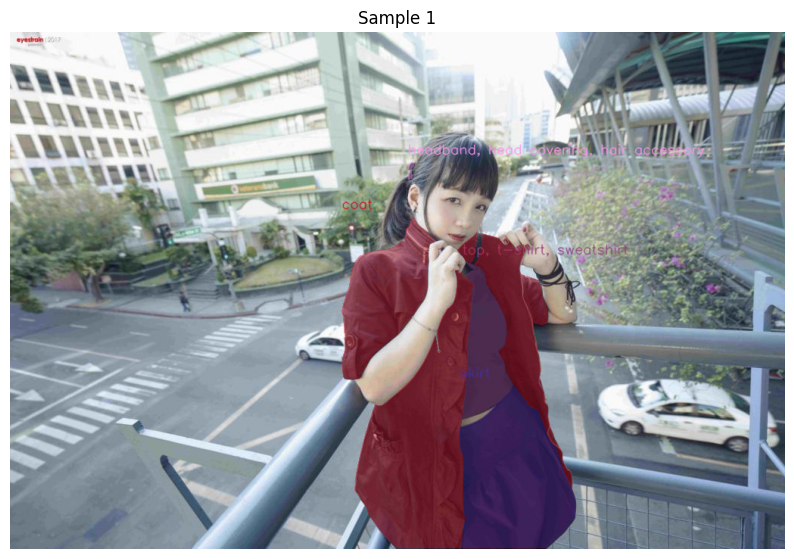

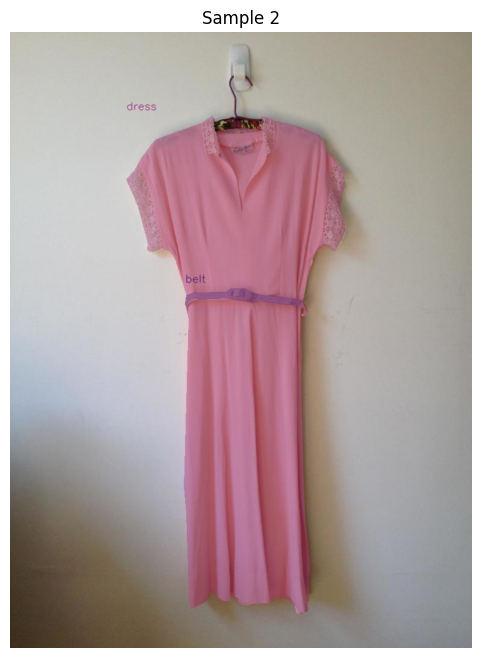

In [8]:
# Label list 
CLASS_NAMES = [ " ",
    "back_bumper", "back_glass", "back_left_door", "back_left_light", "back_right_door",
    "back_right_light", "front_bumper", "front_glass", "front_left_door", "front_left_light",
    "front_right_door", "front_right_light", "hood", "left_mirror", "right_mirror",
    "tailgate", "trunk", "wheel"
]
 

FULL_CLASSES = [' ','shirt, blouse','top, t-shirt, sweatshirt','sweater','cardigan',
                'jacket','vest','pants','shorts','skirt','coat','dress','jumpsuit',
                'cape','glasses','hat','headband, head covering, hair accessory',
                'tie','glove','watch','belt','leg warmer','tights, stockings','sock',
                'shoe','bag, wallet','scarf','umbrella','hood','collar','lapel',
                'epaulette','sleeve','pocket','neckline','buckle','zipper','applique',
                'bead','bow','flower','fringe','ribbon','rivet','ruffle','sequin','tassel']
CLASS_NAMES = FULL_CLASSES[:28]
#NUM_CLASSES = len(MAIN_CLASSES) + 1 #+1 for background

# Get one batch
images, targets = next(iter(train_loader))

print(len(CLASS_NAMES))
 
# loop through one batch and draw bounding boxes and labels
for i in range(len(images)):
    # CxHxW --> HxWxC
    image = images[i].permute(1, 2, 0).cpu().numpy()
    # Rescale
    image = (image * 255).astype(np.uint8)
    # Convert RGB to BGR
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    overlay = image.copy()
     
    # Extract masks, bounding boxes, and labels for the current image
    masks = targets[i]['masks'].cpu().numpy()
    boxes = targets[i]['boxes'].cpu().numpy()
    labels = targets[i]['labels'].cpu().numpy()
 
    for j in range(len(masks)):
        mask = masks[j]
        box = boxes[j]
        label_id = labels[j]
 
        # Get class name from mapping
        class_name = CLASS_NAMES[label_id+1]  # assuming 1-based labels
 
        # Random color
        color = np.random.randint(0, 255, (3,), dtype=np.uint8).tolist()
 
        # Alpha blend mask
        colored_mask = np.zeros_like(image, dtype=np.uint8)
        for c in range(3):
            colored_mask[:, :, c] = mask * color[c]
        alpha = 0.4
        overlay = np.where(mask[..., None], 
                           ((1 - alpha) * overlay + alpha * colored_mask).astype(np.uint8), 
                           overlay)
 
        # Draw label
        x1, y1, x2, y2 = map(int, box)
        cv2.putText(overlay, class_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, color, 1, lineType=cv2.LINE_AA)
 
 
    # Show the result
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Sample {i + 1}")
    plt.show()

In [9]:
import torchvision
from torchvision.models.detection import MaskRCNN
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
 
# Load a pre-trained Mask R-CNN model with a ResNet-50 FPN backbone
model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
 
# Determine the number of classes (including background) from training dataset
# COCO format includes category IDs, and we add +1 for background
num_classes = 28 #len(train_dataset.coco.getCatIds()) + 1
 
# Replace the existing box predictor with a new one for our number of classes
# in_features_box: number of input features to the classification layer
in_features_box = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features_box, num_classes)
 
# Replace the existing mask predictor with a new one for our number of classes
# in_features_mask: number of input channels to the first convolutional layer 
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
 
# Move the model to the specified device (e.g., GPU) for training or inference
model.to(device)

/mnt/a27b1cbf-298a-4896-8528-84006d36fd9e/Nero/Documents/Acadèmic/UPC - MAMME/OR/P2/OR_task2/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/a27b1cbf-298a-4896-8528-84006d36fd9e/Nero/Documents/Acadèmic/UPC - MAMME/OR/P2/OR_task2/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [10]:
# Get parameters that require gradients (the model's trainable parameters)
params = [p for p in model.parameters() if p.requires_grad]
 
# Define the optimizer SGD(Stochastic Gradient Descent) 
optimizer = torch.optim.SGD(params, lr=0.005,
                            momentum=0.9, weight_decay=0.0005)

In [17]:
from tqdm import tqdm

def evaluate_model(model, dataloader, num_classes, device):
    model.eval()
    total_loss=0.0

    #confusion matrix
    print(num_classes)
    conf_mat=torch.zeros((num_classes, num_classes), dtype=torch.int64, device = device)

    with torch.no_grad():
        for images, labels in tqdm(dataloader, total=len(dataloader)):

            #GET OUTPUT MASKS
            images= images[0].to(device)
            imc, imh, imw = images.shape
            y_preds = model([images])#a
            y_preds = y_preds[0]
            if len(y_preds["masks"])==0: 
                print("skipping, empty prediction: model returned nothing")
                continue
            y_preds_masks = y_preds["masks"][0]
            
            
            #REFORMAT THE OUTPUT
            Np = y_preds_masks.shape[0] #numcategories_in_prediction
            y_preds_masks.reshape((Np,imh*imw)) 
            threshold = 0.5
            over = y_preds_masks > threshold #True if >0.5, else false
            over = over.long() #convert to 0s and 1s
            preds = y_preds_masks*over #set all values under 0.5 to zero
            
            #get max across categories, and corresponding category
            preds, cats = torch.max(preds, axis=0) 
            # preds: [0,0.7,0.3,0,0,0,0.3,0.2,... etc]
            # cats: [0,1,0,0,2,0,1,0,4,0,2] (fins a N sent N les 
            # CATEGORIES DIFERENTS A LA FOTO, no les totals)
            preds = [1 if pred!=0 else 0 for pred in preds]
            # [0,1,1,0,0,0,1,1,...etc]
            y_preds_labels = y_preds["labels"]
            # [0,1,23,23,4] 
            whichcats = [y_preds_labels[cat] for cat in cats]
            # [0,1,0,0,2,0,1,0,4...] -> [0,23,0,0,8,0,23,0,7,...]
            preds*=whichcats #fa falta? poder no! és el mateix al final
            preds = preds.long() #idem
            
            #REFORMAT THE TARGET
            labels = labels[0]
            N = labels["masks"].shape[0] #numcategories_in_target
            A = labels["masks"].reshape((N,imh*imw))
            e = torch.tensor(np.zeros([imh*imw]))
            for i in range(len(A)):
                k = int(labels["labels"][i])
                Aik = A[i]*k
                e = e+Aik #assumim que target no té overlapping masks           
            preds= preds.view(-1)
            labels= e.view(-1)

            for t, p in zip(labels, preds):
                if t >= 28 or p>= 28:
                    print(t,p)
                    continue
                conf_mat[t.long(), p.long()] += 1
    
    conf_mat= conf_mat.float()
    #print("confmat",conf_mat.shape,conf_mat)
    TP= torch.diag(conf_mat)
    FP= conf_mat.sum(dim=0)-TP
    FN= conf_mat.sum(dim=1)-TP
    TN= conf_mat.sum()-(TP+FP+FN)

    # Dice per class
    dice_per_class = (2*TP)/(2*TP+FP+FN+1e-6)
    mDice = dice_per_class.mean().item()
    mDice_no_bg = dice_per_class[1:].mean().item()

    # Accuracy per class
    acc_per_class= TP/(TP + FN + 1e-6)
    mAcc= acc_per_class.mean().item()
    mAcc_no_bg= acc_per_class[1:].mean().item()

    # Global accuracy
    accuracy= TP.sum()/conf_mat.sum()

    # IoU
    iou_per_class=TP/(TP+FP+FN+1e-6)
    mIoU= iou_per_class.mean().item()
    #evaluation_loss= total_loss/len(dataloader)
    #return {"loss": evaluation_loss,"mIoU": mIoU, "mDice": mDice,"mDice_no_bg": mDice_no_bg,"accuracy": accuracy.item(),"dice_per_class": dice_per_class.cpu().numpy(),"mean_acc": mAcc,"mean_acc_no_bg": mAcc_no_bg,"accuracy_per_class": acc_per_class.cpu().numpy(),"iou_per_class": iou_per_class.cpu().numpy()}
    return {"mIoU": mIoU, "mDice": mDice,"mDice_no_bg": mDice_no_bg,"accuracy": accuracy.item(),"dice_per_class": dice_per_class.cpu().numpy(),"mean_acc": mAcc,"mean_acc_no_bg": mAcc_no_bg,"accuracy_per_class": acc_per_class.cpu().numpy(),"iou_per_class": iou_per_class.cpu().numpy(), "conf_mat":conf_mat}

In [18]:
from maskrcnn_engine import train_one_epoch, evaluate
 
# Number of epochs for training
num_epochs = 1
 
# Loop through each epoch
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
 
    # Train the model for one epoch, printing status every 25 iterations
    train_one_epoch(model, optimizer, train_loader, device, epoch, print_freq=25)  # Using train_loader for training
 

    results = evaluate_model(model, val_loader, num_classes, device)
    # Evaluate the model on the validation dataset
    #evaluate(model, val_loader, num_classes, device=device)  # Using val_loader for evaluation
 
    # Optionally, save the model checkpoint after each epoch
    torch.save(model.state_dict(), f"model_epoch_{epoch + 1}.pth")


Epoch 1/1
Epoch: [0]  [ 0/23]  eta: 0:07:43  lr: 0.000000  loss: 1.2047 (1.2047)  loss_classifier: 0.3828 (0.3828)  loss_box_reg: 0.2419 (0.2419)  loss_mask: 0.5109 (0.5109)  loss_objectness: 0.0619 (0.0619)  loss_rpn_box_reg: 0.0072 (0.0072)  time: 20.1522  data: 0.7373  max mem: 0
Epoch: [0]  [22/23]  eta: 0:00:24  lr: 0.000005  loss: 1.2284 (1.2435)  loss_classifier: 0.3042 (0.3493)  loss_box_reg: 0.1823 (0.1977)  loss_mask: 0.5783 (0.5757)  loss_objectness: 0.0574 (0.0687)  loss_rpn_box_reg: 0.0246 (0.0521)  time: 24.0556  data: 0.8970  max mem: 0
Epoch: [0] Total time: 0:09:17 (24.2471 s / it)
28


  8%|███▋                                        | 1/12 [00:04<00:51,  4.68s/it]

skipping empty prediction


 17%|███████▎                                    | 2/12 [00:08<00:41,  4.12s/it]

skipping empty prediction


...

skipping empty prediction


 92%|███████████████████████████████████████▍   | 11/12 [00:51<00:04,  4.21s/it]

skipping empty prediction


100%|███████████████████████████████████████████| 12/12 [00:55<00:00,  4.59s/it]

skipping empty prediction


In [13]:
results

{'mIoU': 0.0,
 'mDice': 0.0,
 'mDice_no_bg': 0.0,
 'accuracy': nan,
 'dice_per_class': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 'mean_acc': 0.0,
 'mean_acc_no_bg': 0.0,
 'accuracy_per_class': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 'iou_per_class': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 'conf_mat': tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 